## **MRMS Radar Accumulated Quality Index (RAQI)**

### **Imports**

In [1]:

import numpy as np, random, os, matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta
import gzip
import shutil
from tqdm import tqdm

import boto3
from botocore import UNSIGNED
from botocore.config import Config

import xarray as xr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


### **Paths**

In [2]:

root_path = Path.cwd()
compress_path = root_path / 'data/samples/compress_path'
extraction_path = root_path / 'data/samples/extracted_files'

temporal_compress_path = root_path / "data/samples/temporal_compress"
temporal_extraction_path = root_path / "data/samples/temporal_extracted"

compress_path.mkdir(parents=True, exist_ok=True)
extraction_path.mkdir(parents=True, exist_ok=True)
temporal_compress_path.mkdir(parents=True, exist_ok=True)
temporal_extraction_path.mkdir(parents=True, exist_ok=True)

print(compress_path.exists(), extraction_path.exists(), 
      temporal_compress_path.exists(), temporal_extraction_path.exists())


True True True True



The aim of this project is to improve the **Quantitative Precipitation Estimation (QPE)** in regions where radar observations may appear numerically valid but remain physically unreliable, particularly in **radar-blocked, poor-radar-geometry, and gage-sparse regions**. The broader goal is to develop a **reliability-aware multi-source QPE correction framework** that combines radar precipitation, radar-quality information, gage support, model guidance, and terrain information.
In the previous notebook, we examined **MRMS `RadarOnly_QPE_01H`**, which provides radar-derived precipitation accumulated over the previous hour. Since RadarOnly QPE may not be equally reliable at every location, the next step is to examine the MRMS products that describe **radar observation quality**.

We have two candidates to observe radar observation quality: **Radar Quality Index (RQI)** & **Radar Accumulation Quality Index (RAQI)**. We will use RAQI and see how it is different from RQI. 

### **Radar Quality Index - RQI**

The **Radar Quality Index (RQI)** is a dimensionless indicator of radar QPE quality associated primarily with:

* radar beam blockage due to terrain,
* radar beam height and width,
* and the position of the radar beam relative to the freezing level.

RQI decreases as radar sampling conditions become less favorable. It is produced approximately every **2 minutes**, making it an instantaneous or near-instantaneous indicator of radar quality.

For example:

```text
RQI = 0.90  → relatively favorable radar sampling
RQI = 0.50  → moderate radar sampling quality
RQI = 0.10  → poor radar sampling quality
```

A high RQI does **not guarantee that the precipitation estimate is correct**. It only indicates that the radar sampling conditions are comparatively favorable.

### **Radar Accumulation Quality Index - RAQI**

The **Radar Accumulation Quality Index (RAQI)** extends the radar-quality concept to an accumulated QPE period. MRMS provides several RAQI products, including:

```text
RadarAccumulationQualityIndex_01H
RadarAccumulationQualityIndex_03H
RadarAccumulationQualityIndex_06H
...
```

For this project, the most relevant product is **RadarAccumulationQualityIndex_01H** since we are using hourly radar qpe accumulations. More details:

| Property             | `RadarAccumulationQualityIndex_01H`                   |
| -------------------- | ----------------------------------------------------- |
| Product name         | `RadarAccumulationQualityIndex_01H`                   |
| Physical meaning     | Radar quality associated with 1-hour QPE accumulation |
| Accumulation period  | 1 hour                                                |
| Update interval      | 60 minutes                                            |
| Units                | Dimensionless                                         |
| Spatial resolution   | ~1 km × 1 km                                          |
| Format               | GRIB2                                                 |
| Primary project role | RadarOnly QPE reliability indicator                   |

The operational MRMS product table identifies `RadarAccumulationQualityIndex_01H` specifically as **Radar 1-hour QPE Accumulation Quality**.



Since RadarOnly_QPE_01H represents precipitation accumulated over **one hour**, the corresponding reliability product should describe radar quality over the same accumulation period.
Conceptually:

```text
RadarQualityIndex
        ↓
instantaneous radar quality

RadarAccumulationQualityIndex_01H
        ↓
radar quality associated with the 1-hour QPE accumulation
```

Therefore, **`RadarAccumulationQualityIndex_01H` will be used as the primary radar-reliability variable in this project**, while RQI is useful for understanding the underlying radar-quality concept.

A key hypothesis that will be tested later is:

$$
\text{Higher RAQI}
\rightarrow
\text{more reliable RadarOnly QPE}
\rightarrow
\text{lower error against gage observations}
$$

For example, if the hypothesis is correct:

```text
RAQI = 0.90 → RadarOnly QPE should generally show lower gage-comparison error
RAQI = 0.20 → RadarOnly QPE may show larger gage-comparison error
```

However, this relationship will **not be assumed**. It will later be evaluated empirically by comparing `RadarOnly_QPE_01H` against corresponding gage observations and examining how metrics such as **MAE, RMSE, and bias vary with RAQI**.

---

Next, we will work on downloading a few files, and inspect the metadata, units, value ranges, special identifiers, spatial patterns, and temporal behavior.


### **Data Download**


The 1H radar accumulation quality data are publicly available through the [**NOAA MRMS Amazon S3 archive**](https://noaa-mrms-pds.s3.amazonaws.com/index.html). The archive has the structure:

```text
CONUS/
└── RadarAccumulationQualityIndex_01H_00.00/
    ├── YYYYMMDD/
    │   ├── MRMS_RadarAccumulationQualityIndex_01H_00.00_YYYYMMDD-HHMMSS.grib2.gz
    │   └── ...
```

For example:

```text
MRMS_RadarAccumulationQualityIndex_01H_00.00_20201015-000000.grib2.gz
MRMS_RadarAccumulationQualityIndex_01H_00.00_20201015-010000.grib2.gz
MRMS_RadarAccumulationQualityIndex_01H_00.00_20201015-020000.grib2.gz
```

Unlike `RadarOnly_QPE_01H`, which is updated approximately every 2 minutes, `RadarAccumulationQualityIndex_01H` is produced **hourly**. Therefore, a complete day would theoretically contain:

$$
24\ \text{files/day}
$$

with expected timestamps:

```text
00:00
01:00
02:00
...
23:00
```

However, some days may contain fewer than 24 files because of missing or unavailable timestamps. We will verify the daily file count before downloading the complete historical dataset.

At this stage, we will not download the full archive. Instead, we will select a small number of representative `.grib2.gz` files from a randomly selected day and inspect their **metadata, units, value ranges, special identifiers, spatial patterns, and temporal behavior**. Lets get started.


In [3]:

# NOAA MRMS public S3 bucket
bucket = "noaa-mrms-pds"
product = "CONUS/RadarAccumulationQualityIndex_01H_00.00" # see the above structure

# we can download a random date data between October 16 to onward - 
start_date = datetime(2020, 10, 16)
end_date = datetime.today() - timedelta(days=1)

# get a random date
random_days = random.randint(0, (end_date - start_date).days)
random_date = (start_date + timedelta(days=random_days)).strftime("%Y%m%d")
random_date


'20210623'

In [4]:

# we will use boto3, no need for any credentials, anonymous access
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

prefix = f"{product}/{random_date}/"

# lets see available files for the selected date
response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix) # one requests retrun 1000 files - means the whole day can be 
                                                            # recover with one request 

files = [obj["Key"] for obj in response.get("Contents", []) 
         if obj["Key"].endswith(".grib2.gz")]

files = sorted(files)
print(f"Number of files found: {len(files)}")

# print a few files paths and see which dates/timestamps are missing
available_times = set()
for key in files:
    filename = Path(key).name # the naming example is:  MRMS_RadarAccumulationQualityIndex_01H_00.00_20201015-000000.grib2.gz
    timestamp_str = (filename.split("_")[-1].replace(".grib2.gz", ""))
    available_times.add(datetime.strptime(timestamp_str, "%Y%m%d-%H%M%S"))



day_start = datetime.strptime(random_date, "%Y%m%d")

expected_times = {day_start + timedelta(hours=i) for i in range(24)}
missing_times =  sorted(expected_times - available_times) # this will return the missing times

print(f"Expected files : {len(expected_times)}")
print(f"Available files: {len(available_times)}")
print(f"Missing files  : {len(missing_times)}")

for t in missing_times:
    print(t.strftime("%Y-%m-%d %H:%M:%S"))
    

Number of files found: 24
Expected files : 24
Available files: 24
Missing files  : 0


In [5]:

# now lets download a few timestamps from the same day
sample_files = random.sample(files, 5)

for key in sample_files:
    local_path = compress_path / Path(key).name

    print(f"Downloading: {Path(key).name}")

    s3.download_file(bucket, key, str(local_path))

print("\nDownloaded files:")
for path in sorted(compress_path.glob("*.grib2.gz")):
    print(path)


Downloading: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-180000.grib2.gz
Downloading: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-120000.grib2.gz
Downloading: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-010000.grib2.gz
Downloading: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-220000.grib2.gz
Downloading: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-050000.grib2.gz

Downloaded files:
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/radar_accumulated_quality_index/data/samples/compress_path/MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-010000.grib2.gz
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/radar_accumulated_quality_index/data/samples/compress_path/MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-050000.grib2.gz
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/radar_accumulated_quality_index/data/samp

In [6]:

# lets extract the files and save in the extraction path - we will keep the raw files
for gz_path in compress_path.glob("*.grib2.gz"):
    grib_path = extraction_path / gz_path.name.replace(".gz", "")  

    if not grib_path.exists():
        with gzip.open(gz_path, "rb") as f_in:
            with open(grib_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

        print(f"Created: {grib_path.name}")


Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-220000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-120000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-180000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-010000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-050000.grib2


### **Metadata/Values Inspection**

In this section, we will inspect the downloaded RadarAccumulationQualityIndex_01H GRIB2 files directly to verify their structure and values. We will first examine one sample file for its variable name, units, temporal metadata, grid dimensions, coordinates, and GRIB attributes, and then summarize the sampled files to confirm whether these properties remain consistent.

Because RAQI is a dimensionless quality index, we are particularly interested in verifying:

- Valid-value range
- Whether cfgrib correctly identifies the MRMS-specific variable
- Cccurrence of special values such as -1 (missing) and -3 (no radar coverage)
- Whether the spatial grid and metadata remain consistent across the sampled files

According to the official [MRMS product table](https://www.nssl.noaa.gov/projects/mrms/operational/tables.php), RadarAccumulationQualityIndex_01H is a 60-minute, non-dimensional radar 1-hour QPE accumulation-quality product, with -1 representing missing data and -3 representing no radar coverage.

In [7]:

# lets first get the extracted GRIB files
grib_files = sorted(extraction_path.glob("*.grib2"))

print(f"Number of extracted files: {len(grib_files)}")

# lets select a random file for inspection
sample_path = random.choice(grib_files)

# open the dataset using cfgrib
ds = xr.open_dataset(sample_path, engine="cfgrib")
ds


Number of extracted files: 5


<xarray.Dataset> Size: 98MB
Dimensions:         (latitude: 3500, longitude: 7000)
Coordinates:
    time            datetime64[ns] 8B ...
    step            timedelta64[ns] 8B ...
    heightAboveSea  float64 8B ...
  * latitude        (latitude) float64 28kB 54.99 54.98 54.98 ... 20.02 20.01
  * longitude       (longitude) float64 56kB 230.0 230.0 230.0 ... 300.0 300.0
    valid_time      datetime64[ns] 8B ...
Data variables:
    unknown         (latitude, longitude) float32 98MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             161
    GRIB_centreDescription:  US NOAA Office of Oceanic and Atmospheric Research
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US NOAA Office of Oceanic and Atmospheric Research
    history:                 2026-08-26T23:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [8]:

# it has the same issue as we did with the RadarOnlyQPE. 
# cfgrib/ecCodes is not recognizing the MRMS-specific GRIB parameter definition
# see this below: we will notice data variables as unknown
print("File:", sample_path.name)

print("\nDimensions:")
print(ds.sizes)

print("\nCoordinates:")
print(list(ds.coords))

print("\nData variables:")
print(list(ds.data_vars))

print("\nDataset attributes:")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")
    

File: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-120000.grib2

Dimensions:
Frozen({'latitude': 3500, 'longitude': 7000})

Coordinates:
['time', 'step', 'heightAboveSea', 'latitude', 'longitude', 'valid_time']

Data variables:
['unknown']

Dataset attributes:
GRIB_edition: 2
GRIB_centre: 161
GRIB_centreDescription: US NOAA Office of Oceanic and Atmospheric Research
GRIB_subCentre: 0
Conventions: CF-1.7
institution: US NOAA Office of Oceanic and Atmospheric Research
history: 2026-08-26T23:09 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.47.0 with {"source": "data/samples/extracted_files/MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-120000.grib2", "filter_by_keys": {}, "encode_cf": ["parameter", "time", "geography", "vertical"]}


In [9]:

# lets summarize the data, see the ranges, values, missing/no coverage flags etc.
summary = []

for path in tqdm(grib_files):

    with xr.open_dataset(path, engine="cfgrib") as ds_i:

        da = ds_i[list(ds_i.data_vars)[0]] # get the first data variable
        values = da.values

        # lets get the valid RAQI values: we can get those by excluding negative since
        # we already know that -1 represents missing while -3 represents no coverage.
        valid = values[values >= 0]

        # getting all negative values actually present in the file - should be -1 and -3
        negative_values, negative_counts = np.unique(values[values < 0], return_counts=True)
        negative_summary = dict( zip(negative_values.tolist(), negative_counts.tolist()))

        summary.append({

            "file": path.name,
            "shape": values.shape,
            "dtype": str(values.dtype),

            # raw values - here mean and median will be inflated due to -VE values. 
            "min_raw": np.nanmin(values),
            "max_raw": np.nanmax(values),
            "mean_raw": np.nanmean(values),
            "median_raw": np.nanmedian(values),

            # special/missing values
            "nan_count": np.isnan(values).sum(),
            "negative_count": np.sum(values < 0),
            "minus1_count": np.sum(values == -1),
            "minus3_count": np.sum(values == -3),
            "negative_values_present": str(negative_summary),

            # now lets get valid RAQI values only
            "min_valid": np.min(valid),
            "max_valid": np.max(valid),
            "mean_valid": np.mean(valid),
            "median_valid": np.median(valid),
            "p10_valid": np.percentile(valid, 10),
            "p25_valid": np.percentile(valid, 25),
            "p75_valid": np.percentile(valid, 75),
            "p90_valid": np.percentile(valid, 90),

            # useful quality fractions
            "fraction_raqi_lt_0.25": np.mean(valid < 0.25),
            "fraction_raqi_lt_0.50": np.mean(valid < 0.50),
            "fraction_raqi_ge_0.75": np.mean(valid >= 0.75),
            })


summary_df = pd.DataFrame(summary)
summary_df.to_csv("./summary.csv", index=False)
summary_df


100%|████████████████████████████████████████████| 5/5 [00:08<00:00,  1.75s/it]


,file,shape,dtype,min_raw,max_raw,mean_raw,median_raw,nan_count,negative_count,minus1_count,minus3_count,negative_values_present,min_valid,max_valid,mean_valid,median_valid,p10_valid,p25_valid,p75_valid,p90_valid,fraction_raqi_lt_0.25,fraction_raqi_lt_0.50,fraction_raqi_ge_0.75
0,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,"(3500, 7000)",float32,-1.0,1.0,-0.041593,0.0,0,9198697,9198697,0,{-1.0: 9198697},0.0,1.0,0.534574,0.67,0.0,0.03,0.94,0.99,0.356853,0.432794,0.457938
1,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,"(3500, 7000)",float32,-1.0,1.0,-0.041516,0.0,0,9204019,9204019,0,{-1.0: 9204019},0.0,1.0,0.535231,0.67,0.0,0.03,0.94,0.99,0.356772,0.431752,0.459171
2,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,"(3500, 7000)",float32,-1.0,1.0,-0.041803,0.0,0,9203472,9203472,0,{-1.0: 9203472},0.0,1.0,0.534716,0.67,0.0,0.03,0.94,0.99,0.357074,0.433273,0.458252
3,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,"(3500, 7000)",float32,-1.0,1.0,-0.054500,0.0,0,9261105,9261105,0,{-1.0: 9261105},0.0,1.0,0.520108,0.63,0.0,0.02,0.93,0.99,0.371871,0.449204,0.441271
4,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,"(3500, 7000)",float32,-1.0,1.0,-0.041323,0.0,0,9200520,9200520,0,{-1.0: 9200520},0.0,1.0,0.535189,0.67,0.0,0.03,0.94,0.99,0.356491,0.433160,0.458666


Across the five sampled `RadarAccumulationQualityIndex_01H` files, the grid dimensions and value ranges are consistent. Valid RAQI values range from **0 to 1**, as expected for a dimensionless quality index. No NaN values are present.

The only negative identifier observed is **`-1`**, while **`-3` does not occur** in any of the sampled files. According to the official MRMS product table:

- **`-1` = missing value**
- **`-3` = no radar coverage**

Therefore, these RAQI samples contain pixels where the accumulation-quality value is unavailable or undefined, but no pixels explicitly encoded with the `-3` no-radar-coverage identifier.

This differs from the previously inspected `RadarOnly_QPE_01H` samples, where `-3` was present but `-1` was not. The distinction is reasonable because RadarOnly QPE explicitly represents precipitation availability, whereas RAQI represents the **quality of the radar accumulation itself**. Where an accumulation-quality value cannot be assigned, MRMS may encode the pixel as missing (`-1`).

The negative values will therefore be treated as non-physical sentinel values and masked before further statistical or visual analysis.

### **Visual Inspection**
We will visually inspect the sampled RadarAccumulationQualityIndex_01H fields to see spatial structure across CONUS and verify that the values behave consistently with a radar-quality indicator. We expect higher RAQI values in regions with favorable radar sampling and lower values where radar quality is degraded, for example because of terrain blockage, radar range, or poor radar geometry.

We will first inspect an individual RAQI field together with its missing-value mask, and then compare multiple sampled timestamps using a common 0-1 color scale so that spatial and temporal differences can be interpreted consistently.


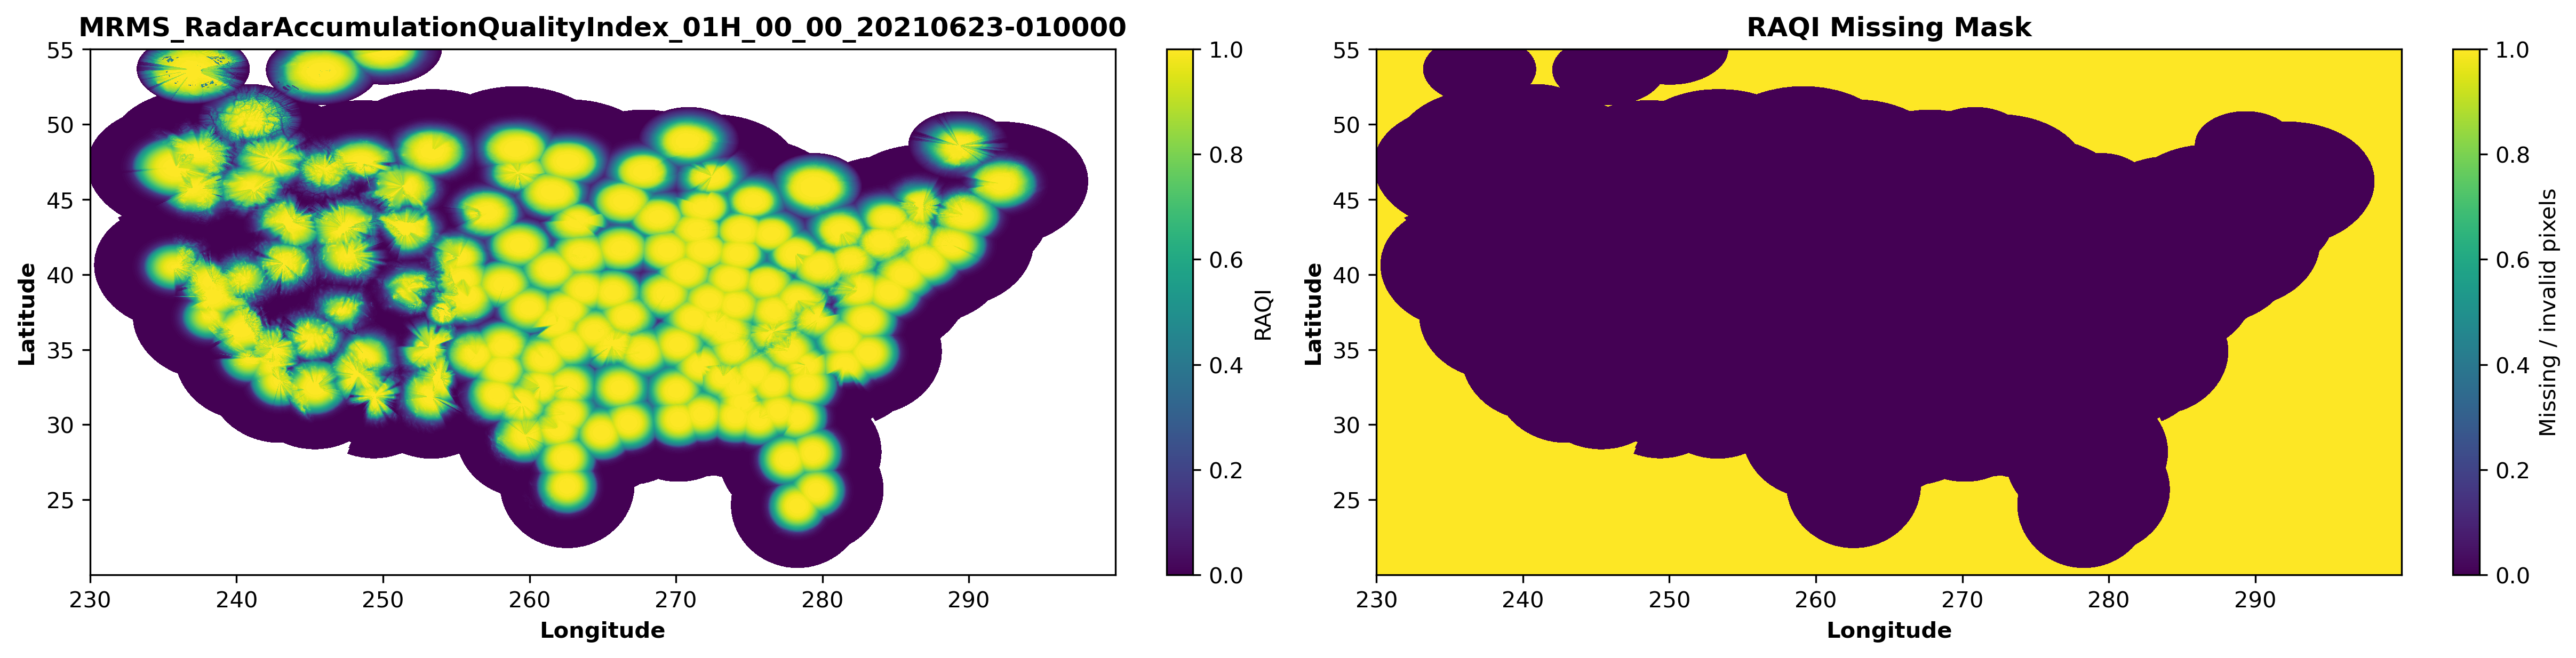

In [10]:

# we will visualize the RAQI field and the missing/invalid mask side by side
sample_path = random.choice(grib_files)

with xr.open_dataset(sample_path, engine="cfgrib") as ds:
    da = ds[list(ds.data_vars)[0]]  # usually named 'unknown'

    # valid RAQI values only
    raqi = da.where(da >= 0)

    # missing/invalid sentinel mask
    invalid_mask = da < 0

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), dpi=300, constrained_layout=True)

    # left: RAQI values
    raqi.plot(
        ax=axes[0],
        x="longitude",
        y="latitude",
        vmin=0,
        vmax=1,
        cbar_kwargs={"label": "RAQI"}
        )

    axes[0].set_title("_".join(sample_path.name.split(".")[:-1]), fontweight="bold", fontsize=12)
    axes[0].set_xlabel("Longitude", fontweight="bold")
    axes[0].set_ylabel("Latitude", fontweight="bold")

    # right: invalid / missing mask
    invalid_mask.plot(
        ax=axes[1],
        x="longitude",
        y="latitude",
        cbar_kwargs={"label": "Missing / invalid pixels"}
        )

    axes[1].set_title("RAQI Missing Mask", fontweight="bold", fontsize=12)
    axes[1].set_xlabel("Longitude", fontweight="bold")
    axes[1].set_ylabel("Latitude", fontweight="bold")

    plt.show()
    

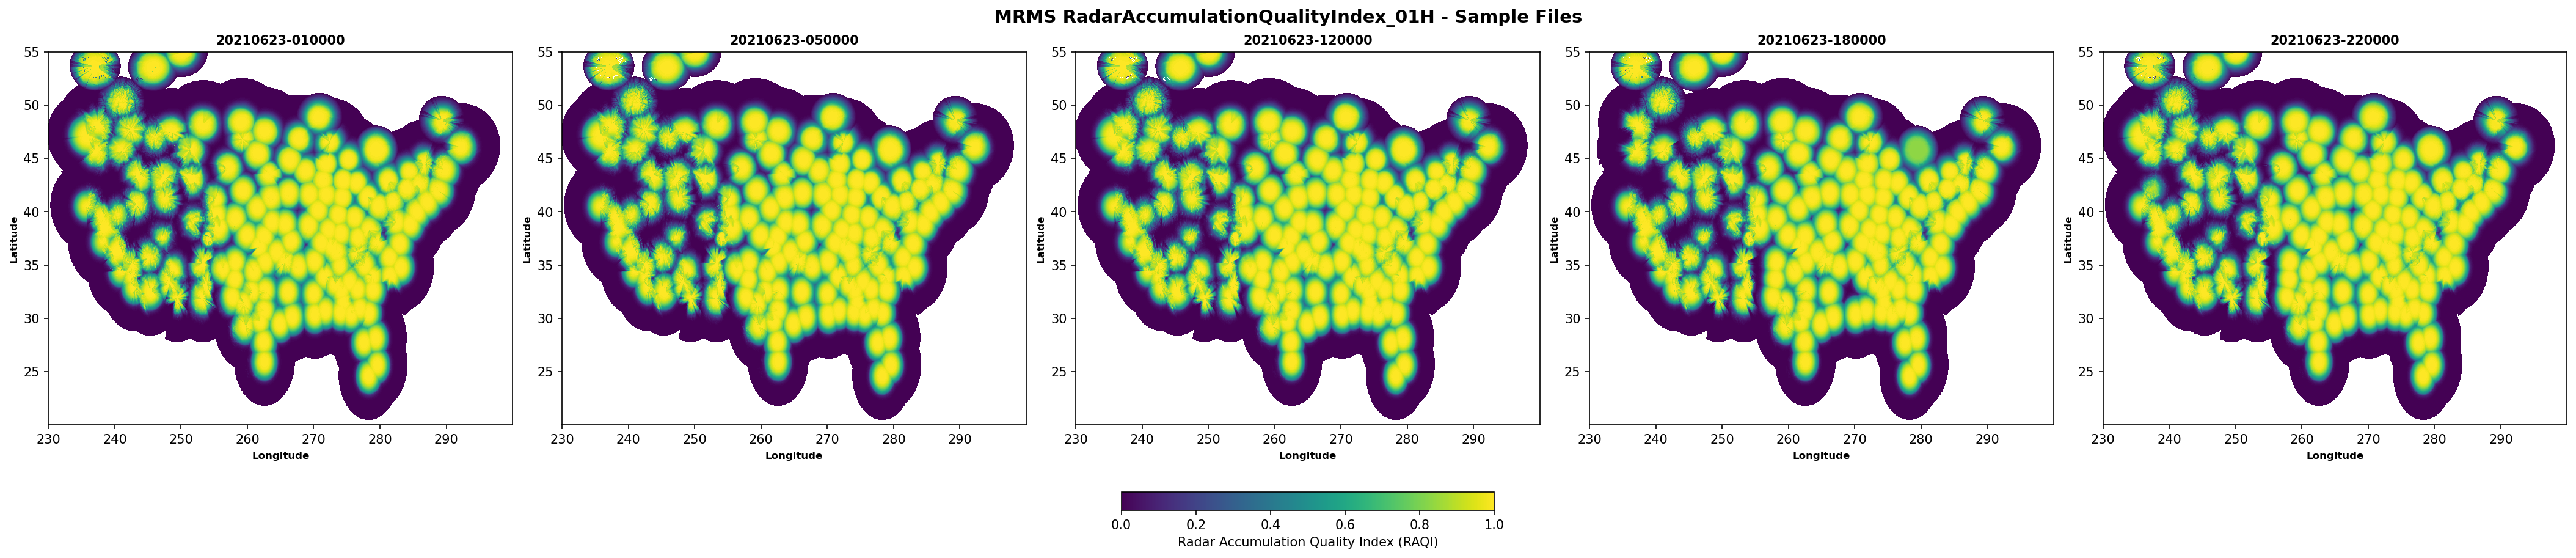

In [11]:

# now lets visualize all sampled files using a common color scale
fig, axes = plt.subplots(1, len(grib_files), figsize=(28, 6), dpi=150, constrained_layout=True)

# if only one file exists, make axes iterable
if len(grib_files) == 1:
    axes = [axes]

for ax, path in zip(axes, grib_files):

    with xr.open_dataset(path, engine="cfgrib") as ds_i:
        da = ds_i[list(ds_i.data_vars)[0]]

        # mask negative sentinel values
        raqi = da.where(da >= 0)

        im = raqi.plot(
            ax=ax,
            x="longitude",
            y="latitude",
            vmin=0,
            vmax=1,
            add_colorbar=False
            )

        timestamp = path.stem.split("_")[-1]

        ax.set_title(timestamp, fontweight="bold", fontsize=10)
        ax.set_xlabel("Longitude", fontweight='bold', fontsize=8)
        ax.set_ylabel("Latitude", fontweight='bold', fontsize=8)

fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    label="Radar Accumulation Quality Index (RAQI)"
    )

plt.suptitle("MRMS RadarAccumulationQualityIndex_01H - Sample Files", fontweight="bold", fontsize=14)
plt.show()

The five sampled RAQI fields show a highly consistent spatial pattern across the day. Large portions of the central and eastern CONUS show high RAQI values close to 1, while lower-quality regions are more common in the western United States, particularly in areas of complex terrain.

The repeated circular and overlapping patterns are consistent with the spatial footprints of individual radar sites. Lower RAQI values appear near the edges of some radar coverage areas and in regions where radar sampling conditions are less favorable.

Across the sampled timestamps, the spatial structure changes little, suggesting that much of the RAQI pattern is controlled by relatively stable factors such as radar geometry and terrain, while smaller temporal variations may arise from atmospheric conditions used in the quality calculation.


### **Temporal Inspection**

Here we will inspect consecutive `RadarAccumulationQualityIndex_01H` files at their expected **1-hour interval** and examine how the radar-quality field changes through time.

Unlike precipitation, RAQI is expected to be relatively stable because much of its spatial structure is controlled by persistent factors such as **radar geometry, beam blockage, and terrain**. However, some temporal variation may still occur because the quality calculation also depends on atmospheric conditions, including the relationship between radar beam height and the freezing level.

Therefore, consecutive hourly RAQI fields should generally remain similar, with gradual changes rather than large abrupt differences. Large unexpected changes could indicate timing issues, missing files, or unusual changes in the quality field.

In [12]:

# select 4 consecutive hourly files around the middle of the day
mid_idx = len(files) // 2
temporal_files = files[mid_idx:mid_idx + 4]

# download and extract them
for key in temporal_files:

    gz_path = temporal_compress_path / Path(key).name

    s3.download_file(bucket, key, str(gz_path))

    grib_path = temporal_extraction_path / gz_path.name.replace(".gz", "")

    with gzip.open(gz_path, "rb") as f_in:
        with open(grib_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    print(f"Created: {grib_path.name}")
    

Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-120000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-130000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-140000.grib2
Created: MRMS_RadarAccumulationQualityIndex_01H_00.00_20210623-150000.grib2


In [13]:

# inspect file times
temporal_gribs = sorted(temporal_extraction_path.glob("*.grib2"))

temporal_summary = []
for path in temporal_gribs:

    with xr.open_dataset(path, engine="cfgrib") as ds_i:

        temporal_summary.append({
            "file": path.name,
            "time": ds_i["time"].values if "time" in ds_i.coords else None,
            "step": ds_i["step"].values if "step" in ds_i.coords else None,
            "valid_time": ds_i["valid_time"].values if "valid_time" in ds_i.coords else None
            })

temporal_df = pd.DataFrame(temporal_summary)
temporal_df


,file,time,step,valid_time
0,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,2021-06-23 12:00:00,0 days,2021-06-23 12:00:00
1,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,2021-06-23 13:00:00,0 days,2021-06-23 13:00:00
2,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,2021-06-23 14:00:00,0 days,2021-06-23 14:00:00
3,MRMS_RadarAccumulationQualityIndex_01H_00.00_2...,2021-06-23 15:00:00,0 days,2021-06-23 15:00:00


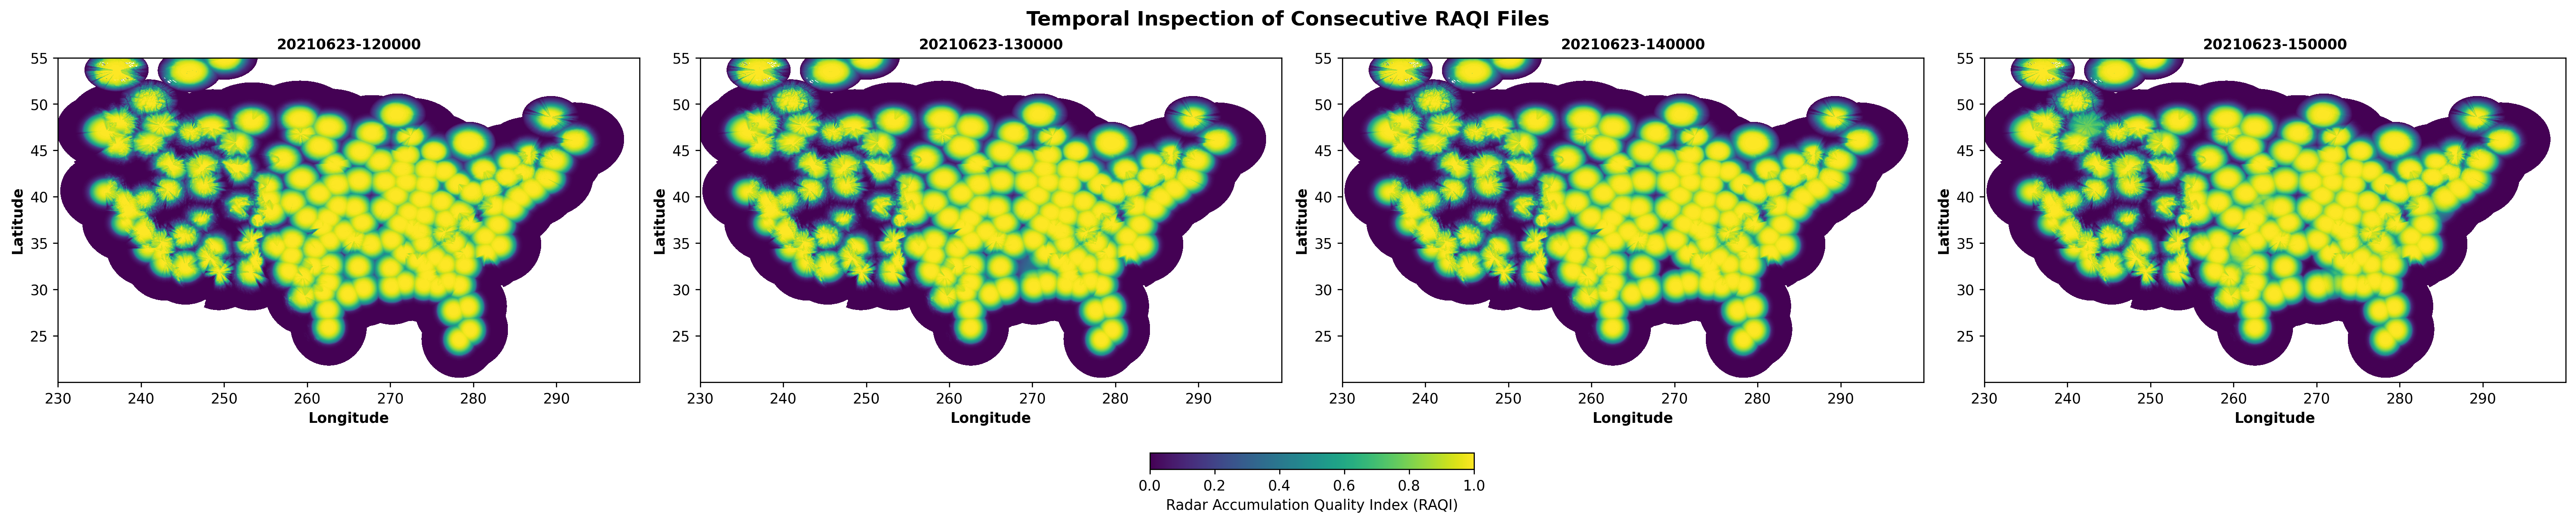

In [14]:

# visualize consecutive hourly RAQI fields
fig, axes = plt.subplots(1, len(temporal_gribs), figsize=(25, 5),
                            dpi=250, constrained_layout=True)

if len(temporal_gribs) == 1:
    axes = [axes]

for ax, path in zip(axes, temporal_gribs):
    with xr.open_dataset(path, engine="cfgrib") as ds_i:
        da = ds_i[list(ds_i.data_vars)[0]]

        # mask negative sentinel values
        raqi = da.where(da >= 0)

        im = raqi.plot(
            ax=ax,
            x="longitude",
            y="latitude",
            vmin=0,
            vmax=1,
            add_colorbar=False
            )

        timestamp = path.stem.split("_")[-1]

        ax.set_title(timestamp, fontweight="bold", fontsize=10)
        ax.set_xlabel("Longitude", fontweight="bold")
        ax.set_ylabel("Latitude", fontweight="bold")

fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    label="Radar Accumulation Quality Index (RAQI)"
    )

plt.suptitle("Temporal Inspection of Consecutive RAQI Files", fontweight="bold", fontsize=14)
plt.show()



The four consecutive hourly RAQI fields are nearly identical in their large-scale spatial structure. High-quality regions remain consistently high, while lower-quality areas, especially over the western CONUS and around radar-coverage edges, remain spatially persistent from 12:00 to 15:00.

Only small localized changes are visible between consecutive hours. This is consistent with the expectation that RAQI is dominated by relatively stable factors such as radar geometry, beam blockage, and terrain, with more limited short-term variability from atmospheric conditions.


### **Conclusion**

This notebook examined the MRMS **Radar Accumulation Quality Index (RAQI)** and its relationship to the underlying **Radar Quality Index (RQI)**. RQI describes near-instantaneous radar sampling quality and is updated approximately every 2 minutes, while `RadarAccumulationQualityIndex_01H` represents the radar-quality information associated with a **1-hour QPE accumulation** and is produced hourly. Because this project uses `RadarOnly_QPE_01H` as the primary radar precipitation input, `RadarAccumulationQualityIndex_01H` provides the more appropriate temporally matched radar-reliability indicator.

The inspection of the sampled RAQI data showed:

* The selected day contained the expected **24 hourly files**, with no missing timestamps.
* Each file uses the MRMS CONUS grid with dimensions **3500 × 7000**.
* `cfgrib/ecCodes` does not recognize the MRMS-specific parameter definition and therefore exposes the variable as `unknown`, although the underlying data array is readable.
* Valid RAQI values range from **0 to 1**, consistent with a dimensionless quality index.
* Spatially, RAQI exhibits clear radar-footprint patterns. Higher values are widespread across much of the central and eastern CONUS, while lower values occur more frequently in the western United States and other areas with less favorable radar sampling conditions.
* Consecutive hourly fields are highly similar, indicating that the large-scale RAQI pattern is temporally stable. This is consistent with the strong influence of persistent factors such as **terrain, beam blockage, and radar geometry**, with smaller temporal variations associated with atmospheric conditions.

Overall, `RadarAccumulationQualityIndex_01H` appears suitable for use as a **candidate radar-reliability input** in this project. However, RAQI should not be interpreted as a direct measure of QPE error. A high RAQI indicates favorable radar sampling conditions, but does not guarantee that the corresponding RadarOnly QPE value is accurate.

A later analysis will therefore explicitly test the working hypothesis:

$$
\text{Higher RAQI}
\rightarrow
\text{more reliable RadarOnly QPE}
\rightarrow
\text{lower error against gage observations}
$$

This will be evaluated by comparing `RadarOnly_QPE_01H` with colocated gage observations and stratifying metrics such as **MAE, RMSE, and bias by RAQI level**. The relationship will be treated as an empirical hypothesis rather than assumed in advance.

---



### **References**

**[1] NOAA Warning Decision Training Division — Radar Quality Index (RQI)**
Official MRMS documentation describing RQI, including its physical interpretation, dependence on radar beam blockage and beam height relative to the freezing level, approximately 1-km spatial resolution, and 2-minute temporal resolution.
https://vlab.noaa.gov/web/wdtd/-/radar-quality-index-rqi-?selectedFolder=668045

**[2] NOAA/NSSL — Operational MRMS GRIB2 Product Tables**
Official MRMS product table listing `RadarAccumulationQualityIndex_01H`, its **60-minute update interval**, non-dimensional units, special identifiers (`-1` and `-3`), and description as **Radar 1-hour QPE Accumulation Quality**.
https://www.nssl.noaa.gov/projects/mrms/operational/tables.php

**[3] NOAA/NCEP — MRMS Version 12 Upgrade Supplemental Documentation**
Provides documentation for the MRMS v12 product suite and the Radar Accumulation Quality Index products associated with accumulated radar QPE periods.
https://www.nco.ncep.noaa.gov/pmb/changes/MRMS_SCN_v12.0_Upgrade_Supplemental.pdf

**[4] NOAA Warning Decision Training Division — QPE Mosaic Process**
Describes how RQI is used in MRMS radar mosaicking and explains how higher RQI represents more favorable radar sampling with reduced effects from terrain blockage and unfavorable beam geometry.
https://vlab.noaa.gov/web/wdtd/-/qpe-mosaic-process

**[5] NOAA — MRMS Dataset, Registry of Open Data on AWS**
Provides the official overview of the MRMS system, public AWS access information, operational history, and general MRMS data availability.
https://registry.opendata.aws/noaa-mrms-pds/

**[6] NOAA MRMS Public AWS Archive**
Primary archive from which the raw `RadarAccumulationQualityIndex_01H` GRIB2 files used in this notebook were downloaded.
https://noaa-mrms-pds.s3.amazonaws.com/index.html

**[7] NOAA/NCEP — Operational RadarAccumulationQualityIndex_01H Directory**
Provides the current operational hourly `RadarAccumulationQualityIndex_01H` files and confirms the hourly timestamp structure of the product.
https://mrms.ncep.noaa.gov/2D/RadarAccumulationQualityIndex_01H/

**[8] NOAA/NSSL — Multi-Radar/Multi-Sensor System**
General official MRMS system overview and documentation entry point.
https://www.nssl.noaa.gov/projects/mrms/
